In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, zarr_dir, images_dir, surface_drifters, depth_drifters, depth_100, depth_50
from swot import browse_swot_250m, browse_swot_2km, add_mask_inside_swot, build_swath_polygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pynsitu as pyn

In [13]:
# TO CHOOSE 
from cstes import drifters_dir
ds = xr.open_dataset(os.path.join(drifters_dir,'L2', 'all_med_variational_1h_v0.nc'))
ds =ds.where(ds.gap_mask==1).where(ds.datetime<pd.to_datetime('2023-07-15T00:00:00.000000000'), drop=True)

In [3]:
ds

<xarray.Dataset> Size: 187MB
Dimensions:             (drifter_id: 161, datetime: 8061)
Coordinates:
  * datetime            (datetime) datetime64[ns] 64kB 2023-03-27T13:00:00 .....
  * drifter_id          (drifter_id) <U15 10kB '283' '4389439' ... '4694203'
Data variables: (12/18)
    x                   (drifter_id, datetime) float64 10MB nan nan ... nan nan
    y                   (drifter_id, datetime) float64 10MB nan nan ... nan nan
    drifter_type        (drifter_id, datetime) object 10MB nan nan ... nan nan
    cruise_id           (drifter_id, datetime) object 10MB nan nan ... nan nan
    lonc                (drifter_id, datetime) float64 10MB nan nan ... nan nan
    latc                (drifter_id, datetime) float64 10MB nan nan ... nan nan
    ...                  ...
    acceleration_north  (drifter_id, datetime) float64 10MB nan nan ... nan nan
    acceleration        (drifter_id, datetime) float64 10MB nan nan ... nan nan
    X                   (drifter_id, datetime) float64 10MB nan nan ... nan nan
    gap_mask            (drifter_id, datetime) float64 10MB nan nan ... nan nan
    gaps                (drifter_id, datetime) float64 10MB nan nan ... nan nan
    sign_acceleration   (drifter_id, datetime) float64 10MB nan nan ... nan nan
Attributes:
    description:                     L2 product - applied smoothing method on...
    smoothing_method:                Variational
    smoothing_method_param_dict:     {'acc_cut': 0.0003, 'position_error': 70...
    interpolation_sampling:          1h
    version:                         v0
    geographical_projection:         Asimuthal Equidistant projection centere...
    geographical_projection_pyproj:  pyproj.Proj(proj="aeqd", lat_0=latc, lon...
    citation_str:                    
    distribution_str:                These data were collected and made freel...
    generation_date:                 2024-12-02 15:03:37.289500

In [4]:
dfs = browse_swot_2km()

In [5]:
files_c = dfs[dfs.cycle_number == 500].file

In [10]:
files_c

day         pass_number
2023-04-23  3              /Users/mdemol/DATA_KARIN/L3_calval_1.0.2/3_500...
2023-04-24  16             /Users/mdemol/DATA_KARIN/L3_calval_1.0.2/16_50...
Name: file, dtype: object

In [6]:
dss3 = xr.open_dataset(files_c.iloc[0])
dss16 = xr.open_dataset(files_c.iloc[1])

In [15]:
dss3["adt"] = (dss3.duacs_ssha_karin_2_filtered +  dss3.cvl_mean_dynamic_topography_cnes_cls_22).assign_attrs({'long_name' : 'ADT from SWOT', 'units':'m'})
dss16["adt"] = (dss16.duacs_ssha_karin_2_filtered +  dss16.cvl_mean_dynamic_topography_cnes_cls_22).assign_attrs({'long_name' : 'ADT from SWOT', 'units':'m'})

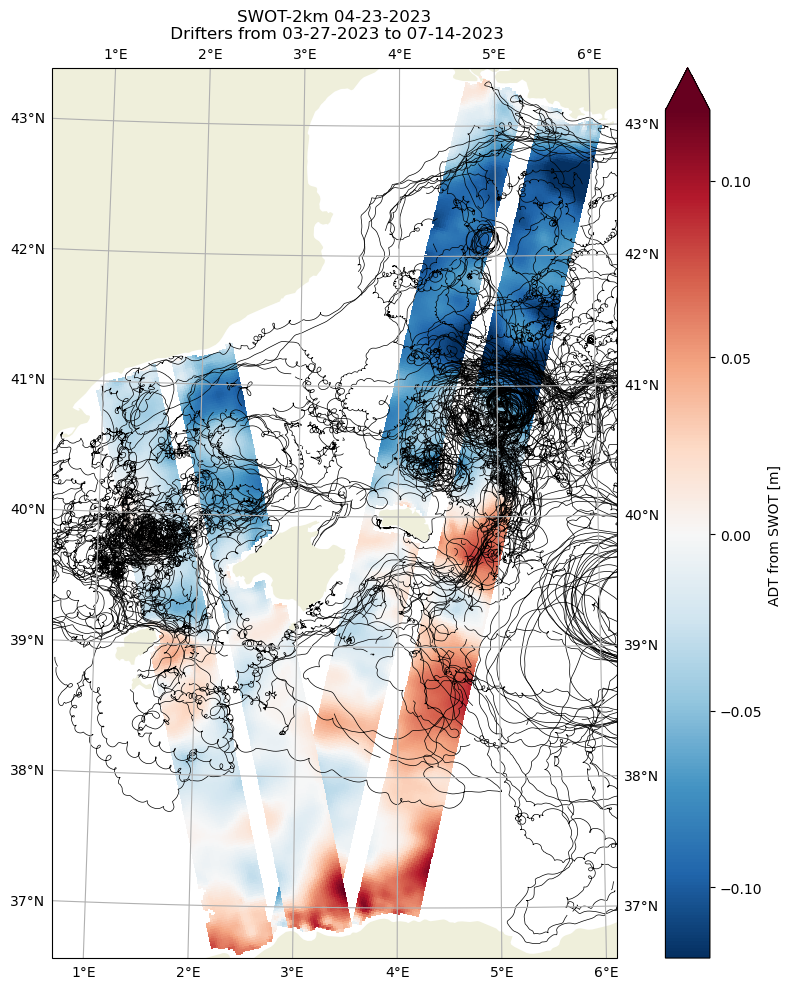

In [16]:
bbox = [0.7, 6.1, 36.6, 43.4]

fig = plt.figure(figsize=(10,10))
fig.patch.set_facecolor('white')#no transparancy in png
ax = fig.add_subplot(111, projection=ccrs.Orthographic(dss3.longitude.mean().values, dss3.latitude.mean().values))
dss3.adt.plot(ax=ax, transform=crs, x='longitude', y='latitude',vmin = -0.12, vmax=0.12, add_colorbar=False, cmap ='RdBu_r')
dss16.adt.plot(ax=ax, transform=crs, x='longitude', y='latitude', vmin = -0.12, vmax=0.12, cmap ='RdBu_r')
for id_ in ds.drifter_id :
    ds_ = ds.sel(drifter_id = id_)
    ax.plot(ds_.longitude, ds_.latitude, transform =crs, c='k', lw=0.5)
ax.add_feature(cfeature.LAND,)
ax.set_extent(bbox)
gl = ax.gridlines(draw_labels=True,)
gl.xlabels_top = False
gl.ylabels_right = False
dtmin = pd.to_datetime(ds.datetime.min().values).strftime("%m-%d-%Y")
dtmax = pd.to_datetime(ds.datetime.max().values).strftime("%m-%d-%Y")
ax.set_title(f'SWOT-2km {pd.to_datetime(dss3.time.mean().values).strftime("%m-%d-%Y")}\n Drifters from {dtmin} to {dtmax}')
fig.tight_layout()